
--- Análisis Exploratorio de Datos (EDA) ---

Primeras filas del dataset combinado:
  Car_Name    Year  Selling_Price  Present_Price  Kms_Driven Fuel_Type  \
0     ritz  2014.0           3.35           5.59     27000.0    Petrol   
1      sx4  2013.0           4.75           9.54     43000.0    Diesel   
2     ciaz  2017.0           7.25           9.85      6900.0    Petrol   
3  wagon r  2011.0           2.85           4.15      5200.0    Petrol   
4    swift  2014.0           4.60           6.87     42450.0    Diesel   

  Seller_Type Transmission Owner name  ...  Seller Type  Engine  Max Power  \
0      Dealer       Manual     0  NaN  ...          NaN     NaN        NaN   
1      Dealer       Manual     0  NaN  ...          NaN     NaN        NaN   
2      Dealer       Manual     0  NaN  ...          NaN     NaN        NaN   
3      Dealer       Manual     0  NaN  ...          NaN     NaN        NaN   
4      Dealer       Manual     0  NaN  ...          NaN     NaN        NaN   

 

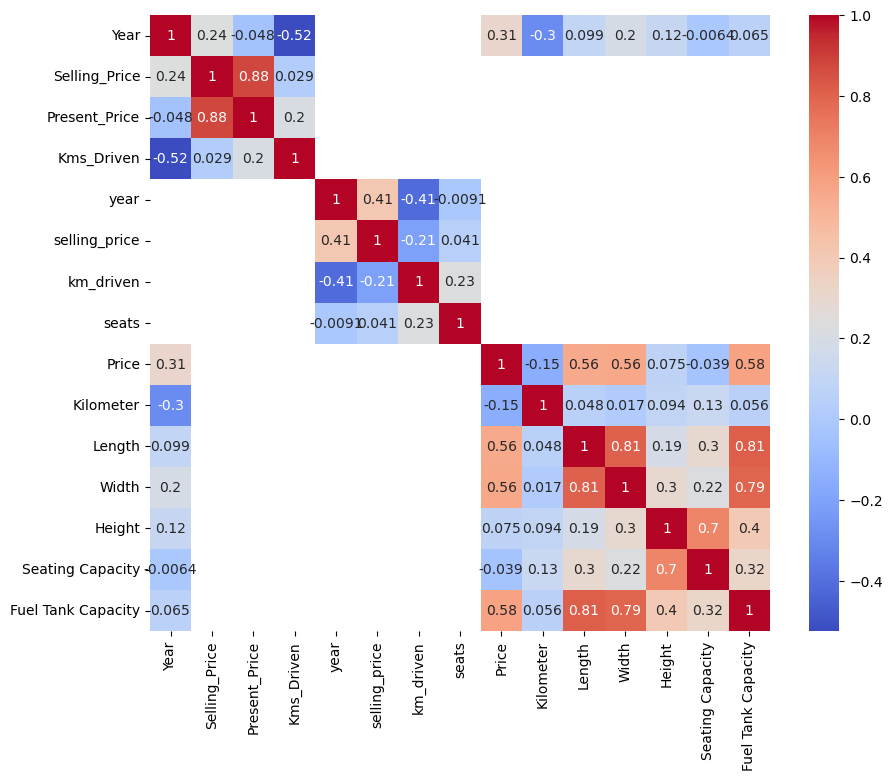


Histogramas de las variables numéricas:


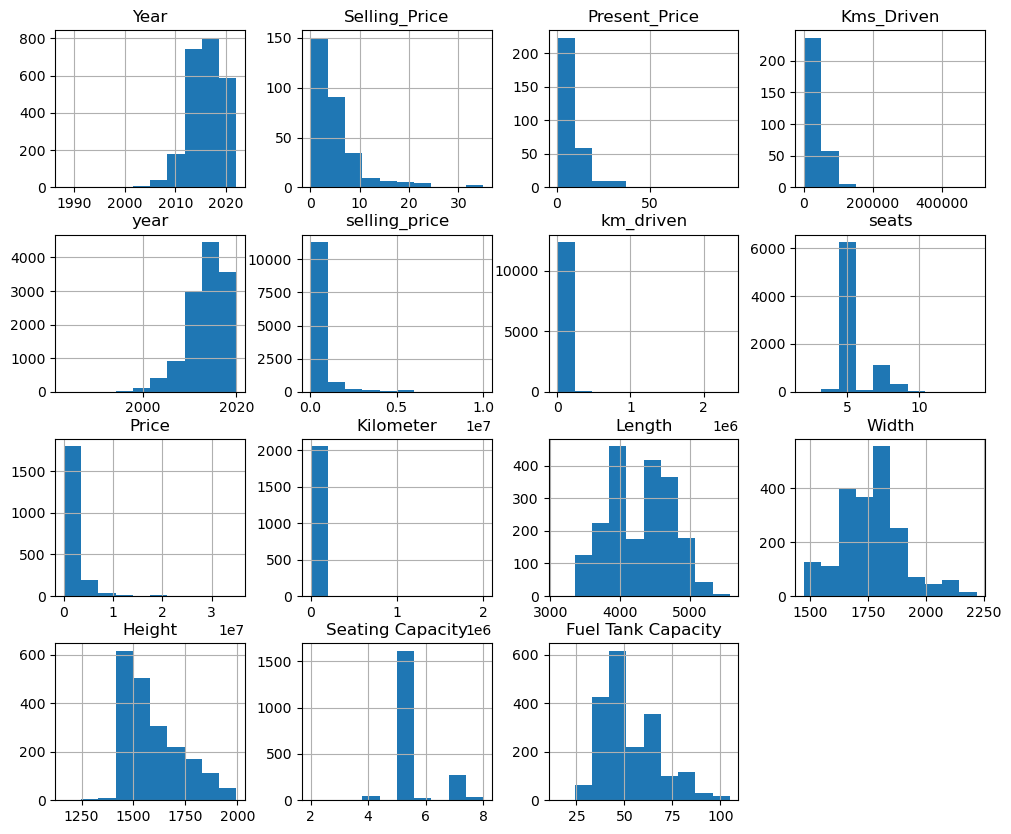


Demasiadas columnas numéricas para pairplot.


In [11]:
import pandas as pd
import os
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Cargar los datos
# Ruta de la carpeta donde están los archivos CSV
folder_path = 'regresionlineal'

# Listar los archivos CSV en la carpeta
csv_files = [f for f in os.listdir(folder_path) if f.endswith('.csv')]

# Verificar si hay archivos CSV
if not csv_files:
    print("Error: No se encontraron archivos CSV en la carpeta.")
    exit()  # Detener la ejecución si no hay archivos

# Cargar los archivos CSV en DataFrames
dfs = []
for csv_file in csv_files:
    file_path = os.path.join(folder_path, csv_file)
    try:
        df = pd.read_csv(file_path)
        dfs.append(df)
    except Exception as e:
        print(f"Error al cargar {csv_file}: {e}")
        continue  # Continuar con el siguiente archivo si hay un error

# Combinar los DataFrames
if dfs:  # Solo combinar si hay DataFrames cargados
    combined_df = pd.concat(dfs, ignore_index=True)
else:
    print("No se cargaron DataFrames. No se puede continuar.")
    exit()

# 2. Análisis Exploratorio de Datos (EDA)
print("\n--- Análisis Exploratorio de Datos (EDA) ---")

# Mostrar las primeras filas del DataFrame
print("\nPrimeras filas del dataset combinado:")
print(combined_df.head())

# Mostrar información general del DataFrame (tipos de datos, valores no nulos, etc.)
print("\nInformación del dataset combinado:")
print(combined_df.info())

# Mostrar estadísticas descriptivas de las columnas numéricas
print("\nEstadísticas descriptivas del dataset combinado:")
print(combined_df.describe())

# 3. Preprocesamiento para el análisis de correlación
# Identificar columnas no numéricas
non_numeric_cols = combined_df.select_dtypes(exclude=['number']).columns
print("\nColumnas no numéricas:", non_numeric_cols)

# Preprocesar columnas no numéricas (Ejemplo: One-Hot Encoding para columnas categóricas)
for col in non_numeric_cols:
    try:
        combined_df = pd.get_dummies(combined_df, columns=[col], drop_first=True)
    except Exception as e:
        print(f"No se pudo aplicar One-Hot Encoding a la columna '{col}': {e}")

# 4. Visualización de la matriz de correlación (después del preprocesamiento)
# Verificar nuevamente los tipos de datos antes de la correlación
print("\nInformación del dataset combinado después de One-Hot Encoding:")
print(combined_df.info())

# Calcular y visualizar la matriz de correlación
try:
    numeric_df = combined_df.select_dtypes(include=['number'])  # Seleccionar solo columnas numéricas
    if not numeric_df.empty:
        print("\nMatriz de correlación:")
        plt.figure(figsize=(10, 8))
        sns.heatmap(numeric_df.corr(), annot=True, cmap='coolwarm')
        plt.show()
    else:
        print("No hay columnas numéricas para calcular la correlación.")
except Exception as e:
    print(f"Error al calcular o visualizar la correlación: {e}")

# 5. Visualización de la distribución de las variables numéricas
print("\nHistogramas de las variables numéricas:")
combined_df.select_dtypes(include=['number']).hist(figsize=(12, 10))
plt.show()

# 6. Visualización de las relaciones entre pares de variables (si no hay demasiadas)
num_cols = combined_df.select_dtypes(include=['number']).shape[1]
if num_cols <= 10 and num_cols > 1:
    print("\nDiagrama de dispersión entre pares de variables numéricas:")
    sns.pairplot(combined_df.select_dtypes(include=['number']))
    plt.show()
elif num_cols > 10:
    print("\nDemasiadas columnas numéricas para pairplot.")
else:
    print("\nNo hay suficientes columnas numéricas para pairplot.")